# Single detector evaluation

This notebook evaluates one ECG peak detector selected either from `algorithms.py`
or from a saved `AlgorithmGraph`.

The primary evaluation uses one-to-one event matching:

- **TP** — a detected peak matched to one QRS annotation,
- **FP** — an unmatched detected peak,
- **FN** — an unmatched QRS annotation.

A true negative is not naturally defined for peak events because almost every ECG
sample is a non-peak. The notebook therefore reports **TN only in a separate,
optional fixed-bin evaluation**. Its result depends on the selected bin size and
must not be mixed with the event-level counts.

In [149]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
from IPython.display import display

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "detector_engine").exists():
    if (REPO_ROOT.parent / "detector_engine").exists():
        REPO_ROOT = REPO_ROOT.parent
    else:
        raise RuntimeError(
            "Could not find detector_engine. Start Jupyter from the repository "
            "root or from a repository subdirectory."
        )

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from detector_engine import AlgorithmGraph, fast_find_peaks, graph_score, load_best_graph

try:
    import algorithms
except ModuleNotFoundError:
    import Algorithms as algorithms

## Configuration

In [150]:
DATA_PATH = REPO_ROOT / "dataset" / "train.pkl"

# Choose exactly one source.
DETECTOR_SOURCE = "graph"  # "algorithm" or "graph"

# Used when DETECTOR_SOURCE == "algorithm".
ALG_LIST = ['alg1_spanish', 'alg4_polish_20210222', 'alg3_iranian', 'alg5_pan_tompkins', 'Alg5_Turkish']
ALGORITHM_NAME = "alg3_iranian"

# Used when DETECTOR_SOURCE == "graph".
DETECTOR_TYPE_DIRS = ['EARLY_NA', 'EARLY_OTHERS', 'EARLY_V', 'LATE_NA', 'LATE_OTHERS', 'LATE_V']
TRIAL_DIRS = ['trial_000', 'trial_001', 'trial_002', 'trial_003', 'trial_004', 'trial_005']
GRAPH_TRIAL_DIRECTORY = REPO_ROOT / "Full_search_artifacts" / "EARLY_NA" / "trial_000"
GRAPH_THRESHOLD_QUANTILE = 0.97
GRAPH_MIN_DISTANCE = 80

QRS_ANNOTATIONS = {
    "N", "L", "R", "V", "/", "A", "f", "F",
    "a", "J", "S", "e", "j", "E", "Q",
}

# A detection matches an annotation when:
# annotation_position + lower <= detection_position <= annotation_position + upper
DEFAULT_MATCH_WINDOW = (-50, 50)

# Optional annotation-specific overrides.
MATCH_WINDOWS_BY_LABEL = {
    # "N": (-40, 40),
    # "V": (-60, 60),
}

# Optional secondary analysis. TN is not naturally defined for peak events.
# Here, each signal is divided into fixed non-overlapping bins.
COMPUTE_BIN_LEVEL_METRICS = True
EVALUATION_BIN_SIZE = 100

## Load the detector

In [138]:
dataset = pd.read_pickle(DATA_PATH)

if DETECTOR_SOURCE == "algorithm":
    if not hasattr(algorithms, ALGORITHM_NAME):
        raise AttributeError(
            f"algorithms has no detector named {ALGORITHM_NAME!r}"
        )
    detector = getattr(algorithms, ALGORITHM_NAME)
    detector_name = ALGORITHM_NAME

elif DETECTOR_SOURCE == "graph":
    _, detector = load_best_graph(GRAPH_TRIAL_DIRECTORY)
    detector_name = GRAPH_TRIAL_DIRECTORY.name

else:
    raise ValueError("DETECTOR_SOURCE must be 'algorithm' or 'graph'")

print("Dataset:", DATA_PATH)
print("Rows:", len(dataset))
print("Detector:", detector_name)
print("Detector source:", DETECTOR_SOURCE)

Dataset: /Users/jeremiasz/code/ekg-evo/new/dataset/test.pkl
Rows: 12
Detector: trial_000
Detector source: graph


In [146]:
import matplotlib.pyplot as plt

DETECTOR_DISPLAY_NAMES = {
    "alg1_spanish": "alg1",
}

# Select any combination of ordinary algorithms and saved graphs.
SELECTED_DETECTORS = [
    "alg1_spanish",
    "alg3_iranian",
    "Alg5_Turkish",

    "evolved_early_na_trial_3",
    "evolved_early_v_trial_0",
    "evolved_early_v_trial_2",
    "evolved_early_v_trial_3",
    # "evolved_late_v_trial_0",
    # "evolved_late_v_trial_1",
    # "evolved_late_v_trial_2",
    # "evolved_late_v_trial_3",
    # "evolved_late_v_trial_4",

    # "evolved_late_na_trial_0",
    # "evolved_late_na_trial_1",
    # "evolved_late_na_trial_2",
    # "evolved_late_na_trial_3",
    # "evolved_late_na_trial_4",

    # "evolved_early_na_trial_0",
    # "evolved_early_na_trial_1",
    # "evolved_early_na_trial_2",
    # "evolved_early_na_trial_3",
    # "evolved_early_na_trial_4",

    "evolved_early_others_trial_0",
    # "evolved_early_others_trial_1",
    # "evolved_early_others_trial_2",
    # "evolved_early_others_trial_3",
    # "evolved_early_others_trial_4",

    # "evolved_late_others_trial_0",
    # "evolved_late_others_trial_1",
    # "evolved_late_others_trial_2",
    # "evolved_late_others_trial_3",
    # "evolved_late_others_trial_4",
]


# Map graph names to their trial directories.
GRAPH_TRIALS = {
    "evolved_early_na_trial_3": (
        REPO_ROOT
        / "Full_search_artifacts"
        / "EARLY_NA"
        / "trial_003"
    ),
    "evolved_early_v_trial_0": (
        REPO_ROOT
        / "Full_search_artifacts"
        / "EARLY_V"
        / "trial_000"
    ),

    "evolved_late_na_trial_3": (
        REPO_ROOT
        / "Full_search_artifacts"
        / "LATE_NA"
        / "trial_000"
    ),
    "evolved_late_v_trial_0": (
        REPO_ROOT
        / "Full_search_artifacts"
        / "LATE_V"
        / "trial_000"
    ),
    "evolved_late_v_trial_1": (
        REPO_ROOT
        / "Full_search_artifacts"
        / "LATE_V"
        / "trial_001"
    ),
    "evolved_late_v_trial_2": (
        REPO_ROOT
        / "Full_search_artifacts"
        / "LATE_V"
        / "trial_002"
    ),
    "evolved_late_v_trial_3": (
        REPO_ROOT
        / "Full_search_artifacts"
        / "LATE_V"
        / "trial_003"
    ),
    "evolved_late_v_trial_4": (
        REPO_ROOT
        / "Full_search_artifacts"
        / "LATE_V"
        / "trial_004"
    ),


    "evolved_late_na_trial_0": (
        REPO_ROOT
        / "Full_search_artifacts"
        / "LATE_NA"
        / "trial_000"
    ),
    "evolved_late_na_trial_1": (
        REPO_ROOT
        / "Full_search_artifacts"
        / "LATE_NA"
        / "trial_001"
    ),
    "evolved_late_na_trial_2": (
        REPO_ROOT
        / "Full_search_artifacts"
        / "LATE_NA"
        / "trial_002"
    ),
    "evolved_late_na_trial_3": (
        REPO_ROOT
        / "Full_search_artifacts"
        / "LATE_NA"
        / "trial_003"
    ),
    "evolved_late_na_trial_4": (
        REPO_ROOT
        / "Full_search_artifacts"
        / "LATE_NA"
        / "trial_004"
    ),

    "evolved_early_na_trial_0": (
        REPO_ROOT
        / "Full_search_artifacts"
        / "EARLY_NA"
        / "trial_000"
    ),
    "evolved_early_na_trial_1": (
        REPO_ROOT
        / "Full_search_artifacts"
        / "EARLY_NA"
        / "trial_001"
    ),
    "evolved_early_na_trial_2": (
        REPO_ROOT
        / "Full_search_artifacts"
        / "EARLY_NA"
        / "trial_002"
    ),
    "evolved_early_na_trial_3": (
        REPO_ROOT
        / "Full_search_artifacts"
        / "EARLY_NA"
        / "trial_003"
    ),
    "evolved_early_na_trial_4": (
        REPO_ROOT
        / "Full_search_artifacts"
        / "EARLY_NA"
        / "trial_004"
    ),

    "evolved_early_v_trial_0": (
        REPO_ROOT
        / "Full_search_artifacts"
        / "EARLY_V"
        / "trial_000"
    ),
    "evolved_early_v_trial_1": (
        REPO_ROOT
        / "Full_search_artifacts"
        / "EARLY_V"
        / "trial_001"
    ),
    "evolved_early_v_trial_2": (
        REPO_ROOT
        / "Full_search_artifacts"
        / "EARLY_V"
        / "trial_002"
    ),
    "evolved_early_v_trial_3": (
        REPO_ROOT
        / "Full_search_artifacts"
        / "EARLY_V"
        / "trial_003"
    ),
    "evolved_early_v_trial_4": (
        REPO_ROOT
        / "Full_search_artifacts"
        / "EARLY_V"
        / "trial_004"
    ),


    "evolved_early_others_trial_0": (
        REPO_ROOT
        / "Full_search_artifacts"
        / "EARLY_NA"
        / "trial_000"
    ),
    "evolved_early_others_trial_1": (
        REPO_ROOT
        / "Full_search_artifacts"
        / "EARLY_NA"
        / "trial_001"
    ),
    "evolved_early_others_trial_2": (
        REPO_ROOT
        / "Full_search_artifacts"
        / "EARLY_NA"
        / "trial_002"
    ),
    "evolved_early_others_trial_3": (
        REPO_ROOT
        / "Full_search_artifacts"
        / "EARLY_NA"
        / "trial_003"
    ),
    "evolved_early_others_trial_4": (
        REPO_ROOT
        / "Full_search_artifacts"
        / "EARLY_OTHERS"
        / "trial_004"
    ),

    "evolved_late_others_trial_0": (
        REPO_ROOT
        / "Full_search_artifacts"
        / "LATE_OTHERS"
        / "trial_000"
    ),
    "evolved_late_others_trial_1": (
        REPO_ROOT
        / "Full_search_artifacts"
        / "LATE_OTHERS"
        / "trial_001"
    ),
    "evolved_late_others_trial_2": (
        REPO_ROOT
        / "Full_search_artifacts"
        / "LATE_OTHERS"
        / "trial_002"
    ),
    "evolved_late_others_trial_3": (
        REPO_ROOT
        / "Full_search_artifacts"
        / "LATE_OTHERS"
        / "trial_003"
    ),
    "evolved_late_others_trial_4": (
        REPO_ROOT
        / "Full_search_artifacts"
        / "LATE_OTHERS"
        / "trial_004"
    ),

}


dataset = pd.read_pickle(DATA_PATH)


def load_selected_detectors(selected_names):
    """
    Load ordinary detector functions and saved AlgorithmGraph objects.

    Dictionary keys are display names used on the plot.
    """
    loaded_detectors = {}

    for detector_name in selected_names:
        display_name = DETECTOR_DISPLAY_NAMES.get(
            detector_name,
            detector_name,
        )

        if hasattr(algorithms, detector_name):
            loaded_detectors[display_name] = getattr(
                algorithms,
                detector_name,
            )
            continue

        if detector_name in GRAPH_TRIALS:
            trial_directory = GRAPH_TRIALS[detector_name]

            if not trial_directory.exists():
                raise FileNotFoundError(
                    f"Graph directory does not exist: "
                    f"{trial_directory}"
                )

            _, graph = load_best_graph(trial_directory)
            loaded_detectors[display_name] = graph
            continue

        available_algorithms = [
            name
            for name in dir(algorithms)
            if not name.startswith("_")
        ]

        raise ValueError(
            f"Unknown detector {detector_name!r}.\n"
            f"It is neither an algorithm function nor a key in "
            f"GRAPH_TRIALS.\n\n"
            f"Available graph names: {list(GRAPH_TRIALS)}\n"
            f"Available algorithm names include: "
            f"{available_algorithms}"
        )

    return loaded_detectors

detectors = load_selected_detectors(SELECTED_DETECTORS)

print("Dataset:", DATA_PATH)
print("Rows:", len(dataset))
print("Selected detectors:")

for detector_name, detector in detectors.items():
    detector_type = (
        "graph"
        if isinstance(detector, AlgorithmGraph)
        else "algorithm"
    )
    print(f"  {detector_name}: {detector_type}")

Dataset: /Users/jeremiasz/code/ekg-evo/new/dataset/test.pkl
Rows: 12
Selected detectors:
  alg1: algorithm
  alg3_iranian: algorithm
  Alg5_Turkish: algorithm
  evolved_early_na_trial_3: graph
  evolved_early_v_trial_0: graph
  evolved_early_v_trial_2: graph
  evolved_early_v_trial_3: graph
  evolved_early_others_trial_0: graph


In [ ]:
import numpy as np
import pandas as pd


MATCH_WINDOW = (-50, 50)

# Use the same settings as during graph evaluation.
GRAPH_THRESHOLD_QUANTILE = 0.97
GRAPH_MIN_DISTANCE = 50

SAMPLING_FREQUENCY = 360


def as_position_array(values):
    """
    Convert detector output to a sorted array of unique sample positions.
    """
    values = np.asarray(values)

    if values.dtype == bool:
        values = np.flatnonzero(values)

    values = values.reshape(-1)

    if len(values) == 0:
        return np.array([], dtype=int)

    values = values.astype(int)

    return np.unique(values)


def run_detector(detector, signal):
    """
    Run an ordinary detector or an AlgorithmGraph.

    Ordinary detectors are expected to return peak positions, possibly
    as the first element of a tuple.

    AlgorithmGraph objects return a score signal which is thresholded
    and passed to the peak finder.
    """
    signal = np.asarray(signal, dtype=float)

    if isinstance(detector, AlgorithmGraph):
        score = graph_score(signal, detector)

        threshold = np.quantile(
            score,
            GRAPH_THRESHOLD_QUANTILE,
        )

        peaks = fast_find_peaks(
            score,
            min_distance=GRAPH_MIN_DISTANCE,
            threshold=threshold,
        )

        return as_position_array(peaks)

    result = detector(signal)

    if isinstance(result, tuple):
        result = result[0]

    return as_position_array(result)


def match_peaks_1to1(
    predicted_peaks,
    true_peaks,
    window=(-50, 50),
):
    """
    Perform one-to-one matching between detected and true peaks.

    A prediction matches an annotation when:

        window[0] <= predicted - true <= window[1]

    Each prediction and annotation can be matched at most once.
    """
    predicted_peaks = np.sort(
        as_position_array(predicted_peaks)
    )
    true_peaks = np.sort(
        as_position_array(true_peaks)
    )

    lower_bound, upper_bound = window

    predicted_index = 0
    true_index = 0

    tp = 0
    fp = 0
    fn = 0

    matched_offsets = []

    while (
        predicted_index < len(predicted_peaks)
        and true_index < len(true_peaks)
    ):
        predicted_position = predicted_peaks[predicted_index]
        true_position = true_peaks[true_index]

        offset = predicted_position - true_position

        if offset < lower_bound:
            # Prediction is too early for this and all later annotations.
            fp += 1
            predicted_index += 1

        elif offset > upper_bound:
            # Annotation cannot be matched by this or any later prediction.
            fn += 1
            true_index += 1

        else:
            tp += 1
            matched_offsets.append(offset)

            predicted_index += 1
            true_index += 1

    # Remaining predictions are false positives.
    fp += len(predicted_peaks) - predicted_index

    # Remaining annotations are false negatives.
    fn += len(true_peaks) - true_index

    return {
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "matched_offsets": matched_offsets,
    }


def safe_divide(numerator, denominator):
    if denominator == 0:
        return np.nan

    return numerator / denominator


def evaluate_detector(
    detector_name,
    detector,
    dataset,
    match_window=(-50, 50),
    sampling_frequency=360,
):
    """
    Evaluate one detector over the complete dataset.
    """
    total_tp = 0
    total_fp = 0
    total_fn = 0

    total_samples = 0
    all_offsets = []

    for _, row in dataset.iterrows():
        signal = np.asarray(
            row["signal"],
            dtype=float,
        )

        true_peaks = as_position_array(
            row["timestamps"]
        )

        predicted_peaks = run_detector(
            detector,
            signal,
        )

        matching_result = match_peaks_1to1(
            predicted_peaks=predicted_peaks,
            true_peaks=true_peaks,
            window=match_window,
        )

        total_tp += matching_result["tp"]
        total_fp += matching_result["fp"]
        total_fn += matching_result["fn"]

        all_offsets.extend(
            matching_result["matched_offsets"]
        )

        total_samples += len(signal)

    sensitivity = safe_divide(
        total_tp,
        total_tp + total_fn,
    )

    precision = safe_divide(
        total_tp,
        total_tp + total_fp,
    )

    f1 = safe_divide(
        2 * precision * sensitivity,
        precision + sensitivity,
    )

    duration_minutes = (
        total_samples
        / sampling_frequency
        / 60
    )

    false_positives_per_minute = safe_divide(
        total_fp,
        duration_minutes,
    )

    absolute_offsets = np.abs(
        np.asarray(all_offsets, dtype=float)
    )

    return {
        "detector": detector_name,
        "TP": total_tp,
        "FP": total_fp,
        "FN": total_fn,
        "sensitivity": sensitivity,
        "recall": sensitivity,
        "specificity": np.nan,
        "precision": precision,
        "F1": f1,
        "FP_per_minute": false_positives_per_minute,
        "mean_absolute_offset": (
            absolute_offsets.mean()
            if len(absolute_offsets) > 0
            else np.nan
        ),
        "median_absolute_offset": (
            np.median(absolute_offsets)
            if len(absolute_offsets) > 0
            else np.nan
        ),
    }


evaluation_results = []

for detector_name, detector in detectors.items():
    print(f"Evaluating {detector_name}...")

    result = evaluate_detector(
        detector_name=detector_name,
        detector=detector,
        dataset=dataset,
        match_window=MATCH_WINDOW,
        sampling_frequency=SAMPLING_FREQUENCY,
    )

    evaluation_results.append(result)


evaluation_df = pd.DataFrame(evaluation_results)

evaluation_df = evaluation_df.sort_values(
    "F1",
    ascending=False,
).reset_index(drop=True)


metric_columns = [
    "sensitivity",
    "recall",
    "precision",
    "F1",
]

evaluation_df[metric_columns] = (
    evaluation_df[metric_columns].round(4)
)

evaluation_df[
    [
        "FP_per_minute",
        "mean_absolute_offset",
        "median_absolute_offset",
    ]
] = evaluation_df[
    [
        "FP_per_minute",
        "mean_absolute_offset",
        "median_absolute_offset",
    ]
].round(2)


display(evaluation_df)

Evaluating alg1...
Evaluating alg3_iranian...
Evaluating Alg5_Turkish...
Evaluating evolved_early_na_trial_3...
Evaluating evolved_early_v_trial_0...
Evaluating evolved_early_v_trial_2...
Evaluating evolved_early_v_trial_3...
Evaluating evolved_early_others_trial_0...


,detector,TP,FP,FN,sensitivity,recall,specificity,precision,F1,FP_per_minute,mean_absolute_offset,median_absolute_offset
0,alg1,27826,980,700,0.9755,0.9755,NaN,0.9660,0.9707,2.71,8.61,7.0
1,evolved_early_v_trial_2,26194,1672,2332,0.9183,0.9183,NaN,0.9400,0.9290,4.63,21.42,19.0
2,Alg5_Turkish,25939,1410,2587,0.9093,0.9093,NaN,0.9484,0.9285,3.90,33.86,37.0
3,evolved_early_v_trial_3,24939,1370,3587,0.8743,0.8743,NaN,0.9479,0.9096,3.79,19.57,19.0
4,evolved_early_others_trial_0,25090,2185,3436,0.8795,0.8795,NaN,0.9199,0.8993,6.05,10.04,9.0
5,evolved_early_na_trial_3,24309,1508,4217,0.8522,0.8522,NaN,0.9416,0.8947,4.18,8.77,7.0
6,evolved_early_v_trial_0,23038,2132,5488,0.8076,0.8076,NaN,0.9153,0.8581,5.90,12.70,11.0
7,alg3_iranian,19986,760,8540,0.7006,0.7006,NaN,0.9634,0.8113,2.10,11.20,7.0


In [9]:
def as_position_array(values, unique=False):
    """
    Convert peak positions to a one-dimensional integer array.

    Parameters
    ----------
    values
        Peak positions.

    unique : bool
        If True, remove duplicate positions.
    """
    if values is None:
        return np.array([], dtype=int)

    positions = np.asarray(values)

    if positions.size == 0:
        return np.array([], dtype=int)

    positions = np.asarray(
        positions,
        dtype=float,
    ).reshape(-1)

    # Remove NaN and infinite values.
    positions = positions[np.isfinite(positions)]

    positions = np.rint(positions).astype(int)

    if unique:
        positions = np.unique(positions)

    return positions
    

def run_selected_detector(signal, detector):
    """
    Run one ordinary detector function or AlgorithmGraph.
    """
    signal = np.asarray(signal, dtype=float)

    if isinstance(detector, AlgorithmGraph):
        score = graph_score(signal, detector)

        threshold = float(
            np.quantile(
                score,
                GRAPH_THRESHOLD_QUANTILE,
            )
        )

        peaks = fast_find_peaks(
            score,
            min_distance=GRAPH_MIN_DISTANCE,
            threshold=threshold,
        )

        return as_position_array(peaks, unique=True)

    result = detector(signal)

    # Some algorithm functions return additional outputs.
    if isinstance(result, tuple):
        if len(result) == 0:
            return np.array([], dtype=int)

        result = result[0]

    return as_position_array(result, unique=True)


def run_all_detectors(signal, selected_detectors=None):
    """
    Run all selected detectors on one ECG signal.
    """
    if selected_detectors is None:
        selected_detectors = detectors

    return {
        detector_name: run_selected_detector(
            signal,
            detector,
        )
        for detector_name, detector in selected_detectors.items()
    }


# def plot_ecg_with_detections(
#     row_index,
#     start_sample=0,
#     end_sample=None,
#     sampling_frequency=None,
#     selected_detectors=None,
#     show_annotations=True,
#     figsize=(12, 6),
#     point_size=35,
# ):
#     """
#     Plot an ECG window with real annotations and detector outputs.

#     Real annotations and detections are displayed as points on
#     separate horizontal lanes above the ECG signal. Dashed vertical
#     lines show the positions of real annotations across all lanes
#     and the ECG plot.
#     """
#     if selected_detectors is None:
#         selected_detectors = detectors

#     signal_column, peak_column, label_column = resolve_schema(
#         dataset
#     )

#     row = dataset.loc[row_index]
#     signal = np.asarray(row[signal_column], dtype=float)

#     if end_sample is None:
#         end_sample = len(signal)

#     start_sample = max(0, int(start_sample))
#     end_sample = min(len(signal), int(end_sample))

#     if start_sample >= end_sample:
#         raise ValueError(
#             "start_sample must be smaller than end_sample"
#         )

#     # Run detectors on the complete signal.
#     all_detections = run_all_detectors(
#         signal,
#         selected_detectors=selected_detectors,
#     )

#     # Load real annotations.
#     annotation_positions = as_position_array(
#         row[peak_column],
#         unique=False,
#     )

#     annotation_labels = np.asarray(
#         row[label_column],
#         dtype=object,
#     )

#     if len(annotation_positions) != len(annotation_labels):
#         raise ValueError(
#             "Annotation positions and labels have different lengths"
#         )

#     # Select annotations from the displayed window.
#     annotation_mask = (
#         (annotation_positions >= start_sample)
#         & (annotation_positions < end_sample)
#     )

#     window_annotations = annotation_positions[annotation_mask]
#     window_labels = annotation_labels[annotation_mask]

#     window_samples = np.arange(start_sample, end_sample)
#     window_signal = signal[start_sample:end_sample]

#     # Configure the x-axis.
#     if sampling_frequency is None:
#         x_values = window_samples
#         x_label = "Sample"

#         def convert_positions(values):
#             return np.asarray(values)

#     else:
#         sampling_frequency = float(sampling_frequency)

#         if sampling_frequency <= 0:
#             raise ValueError(
#                 "sampling_frequency must be positive"
#             )

#         x_values = window_samples / sampling_frequency
#         x_label = "Time [s]"

#         def convert_positions(values):
#             return (
#                 np.asarray(values, dtype=float)
#                 / sampling_frequency
#             )

#     annotation_x = convert_positions(window_annotations)

#     number_of_lanes = len(selected_detectors)

#     if show_annotations:
#         number_of_lanes += 1

#     height_ratios = [0.25] * number_of_lanes + [3.5]

#     fig, axes = plt.subplots(
#         nrows=number_of_lanes + 1,
#         ncols=1,
#         figsize=figsize,
#         sharex=True,
#         constrained_layout=True,
#         gridspec_kw={
#             "height_ratios": height_ratios,
#             "hspace": 0.05,
#         },
#     )

#     # Ensure axes is always indexable.
#     axes = np.atleast_1d(axes)

#     lane_index = 0

#     def configure_detection_axis(ax, label):
#         ax.set_ylabel(
#             label,
#             rotation=0,
#             ha="right",
#             va="center",
#             fontsize = 12
#         )

#         ax.set_ylim(-0.5, 0.5)
#         ax.set_yticks([])

#         # Horizontal line on which the points lie.
#         ax.axhline(
#             y=0,
#             linewidth=1.0,
#             alpha=0.7,
#             zorder=2,
#         )

#         ax.spines["top"].set_visible(False)
#         ax.spines["right"].set_visible(False)
#         ax.spines["left"].set_visible(False)
#         ax.spines["bottom"].set_visible(False)

#         ax.tick_params(
#             axis="x",
#             which="both",
#             bottom=False,
#             labelbottom=False,
#         )

#     # Draw real annotation lines on every subplot.
#     #
#     # Drawing the lines separately on shared-x axes is more reliable
#     # than creating figure-level Line2D objects.
#     if show_annotations and len(annotation_x) > 0:
#         for ax in axes:
#             for x_position in annotation_x:
#                 ax.axvline(
#                     x=x_position,
#                     linewidth=0.9,
#                     linestyle="--",
#                     alpha=0.45,
#                     zorder=1,
#                 )

#     # Real annotation lane.
#     if show_annotations:
#         annotation_ax = axes[lane_index]

#         annotation_ax.scatter(
#             annotation_x,
#             np.zeros(len(annotation_x)),
#             marker="o",
#             s=point_size,
#             zorder=5,
#         )

#         for x_position, label in zip(
#             annotation_x,
#             window_labels,
#         ):
#             annotation_ax.annotate(
#                 str(label),
#                 xy=(x_position, 0),
#                 xytext=(0, 8),
#                 textcoords="offset points",
#                 ha="center",
#                 va="bottom",
#                 fontsize=12,
#                 zorder=6,
#             )

#         configure_detection_axis(
#             annotation_ax,
#             "Real",
#         )

#         lane_index += 1

#     # Detector lanes.
#     for detector_name, detection_positions in (
#         all_detections.items()
#     ):
#         detector_ax = axes[lane_index]

#         detection_mask = (
#             (detection_positions >= start_sample)
#             & (detection_positions < end_sample)
#         )

#         window_detections = detection_positions[
#             detection_mask
#         ]

#         detection_x = convert_positions(
#             window_detections
#         )

#         detector_ax.scatter(
#             detection_x,
#             np.zeros(len(detection_x)),
#             marker="o",
#             s=point_size,
#             zorder=5,
#         )

#         configure_detection_axis(
#             detector_ax,
#             detector_name,
#         )

#         lane_index += 1

#     # ECG signal.
#     signal_ax = axes[-1]

#     signal_ax.plot(
#         x_values,
#         window_signal,
#         linewidth=0.8,
#         zorder=3,
#     )

#     signal_ax.set_ylabel("ECG")
#     signal_ax.set_xlabel(x_label)
#     signal_ax.grid(alpha=0.25)

#     # Keep vertical annotation lines visible over the ECG.
#     if show_annotations and len(annotation_x) > 0:
#         for line in signal_ax.lines[:-1]:
#             line.set_zorder(1)

#     record_id = (
#         row["record"]
#         if "record" in row.index
#         else row_index
#     )

#     if sampling_frequency is None:
#         window_description = (
#             f"samples {start_sample}–{end_sample}"
#         )
#     else:
#         window_description = (
#             f"{start_sample / sampling_frequency:.2f}–"
#             f"{end_sample / sampling_frequency:.2f} s"
#         )

#     fig.suptitle(
#         f"Record {record_id} — {window_description}"
#     )

#     plt.show()

#     return all_detections

AttributeError: 'Text' object has no property 'font_size'

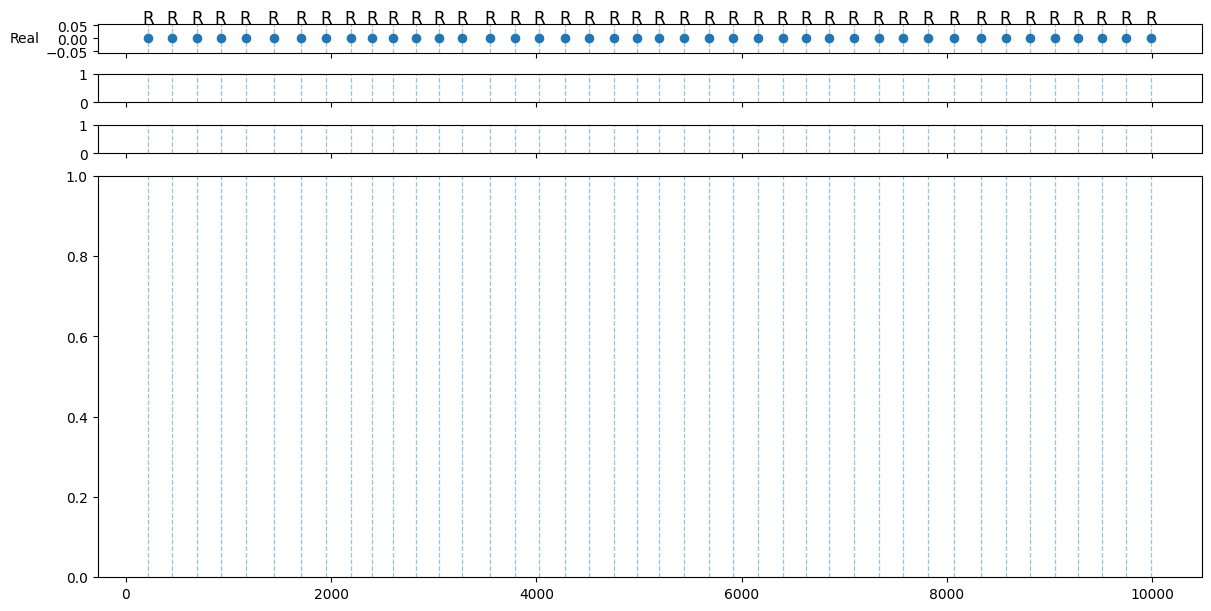

In [ ]:
# detections = plot_ecg_with_detections(
#     row_index=3,
#     start_sample=0_000,
#     end_sample=10_000,
# )

In [10]:
def find_qrs_occurrences(
    qrs_class,
    dataset_to_search=None,
):
    """
    Find all annotations belonging to the selected QRS class.

    Occurrences are ordered by:
    1. dataset row position,
    2. annotation position within the signal.

    Returns
    -------
    pandas.DataFrame
        Columns:
        - occurrence_index
        - row_index
        - row_position
        - record
        - annotation_position
        - qrs_class
    """
    if dataset_to_search is None:
        dataset_to_search = dataset

    _, peak_column, label_column = resolve_schema(
        dataset_to_search
    )

    occurrences = []

    for row_position, (row_index, row) in enumerate(
        dataset_to_search.iterrows()
    ):
        annotation_positions = as_position_array(
            row[peak_column],
            unique=False,
        )

        annotation_labels = np.asarray(
            row[label_column],
            dtype=object,
        )

        if len(annotation_positions) != len(annotation_labels):
            raise ValueError(
                f"Different numbers of positions and labels "
                f"in row {row_index}"
            )

        matching_mask = annotation_labels == qrs_class

        matching_positions = annotation_positions[
            matching_mask
        ]

        # Ensure annotations within one signal are ordered.
        matching_positions = np.sort(matching_positions)

        record_id = (
            row["record"]
            if "record" in row.index
            else row_index
        )

        for annotation_position in matching_positions:
            occurrences.append(
                {
                    "row_index": row_index,
                    "row_position": row_position,
                    "record": record_id,
                    "annotation_position": int(
                        annotation_position
                    ),
                    "qrs_class": qrs_class,
                }
            )

    occurrences_df = pd.DataFrame(occurrences)

    if occurrences_df.empty:
        return pd.DataFrame(
            columns=[
                "occurrence_index",
                "row_index",
                "row_position",
                "record",
                "annotation_position",
                "qrs_class",
            ]
        )

    occurrences_df = occurrences_df.sort_values(
        by=[
            "row_position",
            "annotation_position",
        ],
        kind="stable",
    ).reset_index(drop=True)

    occurrences_df.insert(
        0,
        "occurrence_index",
        np.arange(len(occurrences_df)),
    )

    return occurrences_df

In [27]:
def plot_ecg_with_detections(
    row_index,
    start_sample=0,
    end_sample=None,
    sampling_frequency=None,
    selected_detectors=None,
    show_annotations=True,
    vertical_line_source="Real",
    figsize=(12, 6),
    point_size=35,
):
    """
    Plot an ECG window with real annotations and detector outputs.

    Parameters
    ----------
    vertical_line_source : str or None
        Source used for vertical dashed lines:

        - "Real": real annotation positions,
        - detector name: positions detected by that detector,
        - None: do not draw vertical lines.
    """
    if selected_detectors is None:
        selected_detectors = detectors

    signal_column, peak_column, label_column = resolve_schema(
        dataset
    )

    row = dataset.loc[row_index]
    signal = np.asarray(row[signal_column], dtype=float)

    if end_sample is None:
        end_sample = len(signal)

    start_sample = max(0, int(start_sample))
    end_sample = min(len(signal), int(end_sample))

    if start_sample >= end_sample:
        raise ValueError(
            "start_sample must be smaller than end_sample"
        )

    # Run detectors on the complete signal.
    all_detections = run_all_detectors(
        signal,
        selected_detectors=selected_detectors,
    )

    # Load real annotations.
    annotation_positions = as_position_array(
        row[peak_column],
        unique=False,
    )

    annotation_labels = np.asarray(
        row[label_column],
        dtype=object,
    )

    if len(annotation_positions) != len(annotation_labels):
        raise ValueError(
            "Annotation positions and labels have different lengths"
        )

    # Select annotations from the displayed window.
    annotation_mask = (
        (annotation_positions >= start_sample)
        & (annotation_positions < end_sample)
    )

    window_annotations = annotation_positions[annotation_mask]
    window_labels = annotation_labels[annotation_mask]

    window_samples = np.arange(start_sample, end_sample)
    window_signal = signal[start_sample:end_sample]

    # Configure the x-axis.
    if sampling_frequency is None:
        x_values = window_samples
        x_label = "Sample"

        def convert_positions(values):
            return np.asarray(values)

    else:
        sampling_frequency = float(sampling_frequency)

        if sampling_frequency <= 0:
            raise ValueError(
                "sampling_frequency must be positive"
            )

        x_values = window_samples / sampling_frequency
        x_label = "Time [s]"

        def convert_positions(values):
            return (
                np.asarray(values, dtype=float)
                / sampling_frequency
            )

    annotation_x = convert_positions(window_annotations)

    # Choose positions used for vertical lines.
    if vertical_line_source is None:
        vertical_line_positions = np.array([], dtype=int)

    elif vertical_line_source == "Real":
        vertical_line_positions = window_annotations

    elif vertical_line_source in all_detections:
        source_detections = all_detections[
            vertical_line_source
        ]

        source_mask = (
            (source_detections >= start_sample)
            & (source_detections < end_sample)
        )

        vertical_line_positions = source_detections[
            source_mask
        ]

    else:
        available_sources = [
            "Real",
            *all_detections.keys(),
        ]

        raise ValueError(
            f"Unknown vertical_line_source "
            f"{vertical_line_source!r}. "
            f"Available sources: {available_sources}"
        )

    vertical_line_x = convert_positions(
        vertical_line_positions
    )

    number_of_lanes = len(selected_detectors)

    if show_annotations:
        number_of_lanes += 1

    height_ratios = [0.25] * number_of_lanes + [3.5]

    fig, axes = plt.subplots(
        nrows=number_of_lanes + 1,
        ncols=1,
        figsize=figsize,
        sharex=True,
        constrained_layout=True,
        gridspec_kw={
            "height_ratios": height_ratios,
            "hspace": 0.05,
        },
    )

    axes = np.atleast_1d(axes)
    lane_index = 0

    def configure_detection_axis(ax, label):
        ax.set_ylabel(
            label,
            rotation=0,
            ha="right",
            va="center",
            fontsize = 12
        )

        ax.set_ylim(-0.5, 0.5)
        ax.set_yticks([])

        ax.axhline(
            y=0,
            linewidth=1.0,
            alpha=0.7,
            zorder=2,
        )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_visible(False)
        ax.spines["bottom"].set_visible(False)

        ax.tick_params(
            axis="x",
            which="both",
            bottom=False,
            labelbottom=False,
        )

    # Draw lines from the selected source on every subplot.
    for ax in axes:
        for x_position in vertical_line_x:
            ax.axvline(
                x=x_position,
                linewidth=1.2,
                linestyle="--",
                alpha=0.65,
                zorder=1,
            )

    # Real annotation lane.
    if show_annotations:
        annotation_ax = axes[lane_index]

        annotation_ax.scatter(
            annotation_x,
            np.zeros(len(annotation_x)),
            marker="o",
            s=point_size,
            zorder=5,
        )

        for x_position, label in zip(
            annotation_x,
            window_labels,
        ):
            annotation_ax.annotate(
                str(label),
                xy=(x_position, 0),
                xytext=(0, 8),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=12,
                zorder=6,
            )

        configure_detection_axis(
            annotation_ax,
            "Annotation",
        )

        lane_index += 1

    # Detector lanes.
    for detector_name, detection_positions in (
        all_detections.items()
    ):
        detector_ax = axes[lane_index]

        detection_mask = (
            (detection_positions >= start_sample)
            & (detection_positions < end_sample)
        )

        window_detections = detection_positions[
            detection_mask
        ]

        detection_x = convert_positions(
            window_detections
        )

        detector_ax.scatter(
            detection_x,
            np.zeros(len(detection_x)),
            marker="o",
            s=point_size,
            zorder=5,
        )

        configure_detection_axis(
            detector_ax,
            detector_name,
        )

        lane_index += 1

    # ECG signal.
    signal_ax = axes[-1]

    signal_ax.plot(
        x_values,
        window_signal,
        linewidth=1.5,
        zorder=3,
    )

    signal_ax.set_ylabel("ECG (mV)")
    signal_ax.set_xlabel(x_label)
    signal_ax.grid(alpha=0.25)

    record_id = (
        row["record"]
        if "record" in row.index
        else row_index
    )

    if sampling_frequency is None:
        window_description = (
            f"samples {start_sample}–{end_sample}"
        )
    else:
        window_description = (
            f"{start_sample / sampling_frequency:.2f}–"
            f"{end_sample / sampling_frequency:.2f} s"
        )


    fig.suptitle(
        f"Record {record_id} — {window_description}"
    )

    plt.show()

    return all_detections

In [28]:
def plot_qrs_occurrence(
    qrs_class,
    occurrence_index,
    window=(-300, 300),
    sampling_frequency=None,
    selected_detectors=None,
    show_annotations=True,
    vertical_line_source="Real",
    figsize=(10, 4),
    point_size=35,
    dataset_to_search=None,
):
    if dataset_to_search is None:
        dataset_to_search = dataset

    if len(window) != 2:
        raise ValueError(
            "window must contain exactly two values"
        )

    window_before, window_after = map(int, window)

    if window_before >= window_after:
        raise ValueError(
            "The first window value must be smaller "
            "than the second"
        )

    occurrences = find_qrs_occurrences(
        qrs_class=qrs_class,
        dataset_to_search=dataset_to_search,
    )

    if occurrences.empty:
        raise ValueError(
            f"No annotations of class {qrs_class!r} were found"
        )

    occurrence_index = int(occurrence_index)

    if occurrence_index < 0:
        occurrence_index += len(occurrences)

    if not 0 <= occurrence_index < len(occurrences):
        raise IndexError(
            f"occurrence_index must be between 0 and "
            f"{len(occurrences) - 1}"
        )

    occurrence = occurrences.iloc[occurrence_index]

    row_index = occurrence["row_index"]
    annotation_position = int(
        occurrence["annotation_position"]
    )

    start_sample = annotation_position + window_before
    end_sample = annotation_position + window_after

    print(
        f"Class: {qrs_class} | "
        f"Occurrence: {occurrence_index}/"
        f"{len(occurrences) - 1} | "
        f"Record: {occurrence['record']} | "
        f"QRS position: {annotation_position}"
    )

    all_detections = plot_ecg_with_detections(
        row_index=row_index,
        start_sample=start_sample,
        end_sample=end_sample,
        sampling_frequency=sampling_frequency,
        selected_detectors=selected_detectors,
        show_annotations=show_annotations,
        vertical_line_source=vertical_line_source,
        figsize=figsize,
        point_size=point_size,
    )

    return occurrence, all_detections

Class: V | Occurrence: 1500/2875 | Record: 106 | QRS position: 390977


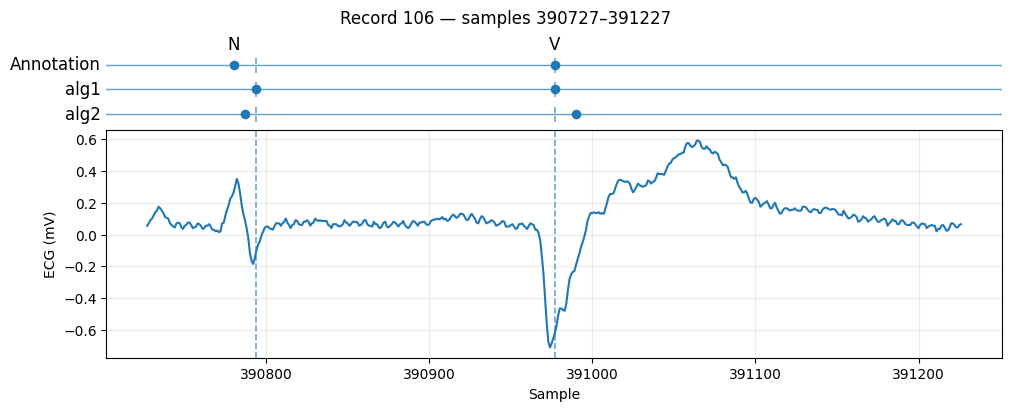

In [134]:
occurrence, detections = plot_qrs_occurrence(
    qrs_class="V",
    occurrence_index=1500,
    window=(-250, 250),
    vertical_line_source="alg1",
)

## Evaluation functions

In [17]:
def resolve_schema(df):
    candidates = (
        ("signal", "timestamps", "annotations"),
        ("ECG", "True_peak", "Peak_type"),
    )

    for candidate in candidates:
        if all(column in df.columns for column in candidate):
            return candidate

    raise ValueError(
        "Expected either signal/timestamps/annotations or "
        "ECG/True_peak/Peak_type columns."
    )


def as_position_array(values, *, unique=False):
    positions = np.asarray(values)

    if positions.ndim == 0:
        positions = positions.reshape(1)
    if positions.ndim != 1:
        raise ValueError(
            f"Peak positions must be one-dimensional, got {positions.shape}"
        )
    if len(positions) == 0:
        return np.array([], dtype=int)

    positions = positions.astype(float)

    if not np.all(np.isfinite(positions)):
        raise ValueError("Peak positions contain NaN or infinity")

    positions = positions.astype(int)
    return np.unique(positions) if unique else positions


def run_detector(signal):
    signal = np.asarray(signal, dtype=float)

    if isinstance(detector, AlgorithmGraph):
        score = graph_score(signal, detector)
        threshold = float(np.quantile(score, GRAPH_THRESHOLD_QUANTILE))
        peaks = fast_find_peaks(
            score,
            min_distance=GRAPH_MIN_DISTANCE,
            threshold=threshold,
        )
        return as_position_array(peaks, unique=True)

    result = detector(signal)

    # Some functions return (peaks, score, threshold) or
    # (peaks, operation_counts). Only the first item is required.
    if isinstance(result, tuple):
        if not result:
            return np.array([], dtype=int)
        result = result[0]

    return as_position_array(result, unique=True)


def match_window(label):
    window = MATCH_WINDOWS_BY_LABEL.get(label, DEFAULT_MATCH_WINDOW)

    if isinstance(window, (int, np.integer)):
        lower, upper = -int(window), int(window)
    else:
        lower, upper = map(int, window)

    if lower > upper:
        raise ValueError(f"Invalid match window for {label!r}: {window}")

    return lower, upper


def match_detections(detections, annotations, labels):
    """Match detector outputs to annotations one-to-one."""
    detections = as_position_array(detections, unique=True)
    annotations = as_position_array(annotations, unique=False)
    labels = np.asarray(labels, dtype=object)

    if len(annotations) != len(labels):
        raise ValueError("Annotation positions and labels have different lengths")

    candidates = []

    for detection_index, detection in enumerate(detections):
        for annotation_index, (annotation, label) in enumerate(
            zip(annotations, labels)
        ):
            lower, upper = match_window(str(label))
            offset = int(detection - annotation)

            if lower <= offset <= upper:
                candidates.append(
                    (
                        abs(offset),
                        detection_index,
                        annotation_index,
                        offset,
                    )
                )

    candidates.sort()

    matched_detections = set()
    matched_annotations = set()
    matches = []

    for _, detection_index, annotation_index, offset in candidates:
        if detection_index in matched_detections:
            continue
        if annotation_index in matched_annotations:
            continue

        matched_detections.add(detection_index)
        matched_annotations.add(annotation_index)

        matches.append(
            {
                "detection": int(detections[detection_index]),
                "annotation": int(annotations[annotation_index]),
                "label": str(labels[annotation_index]),
                "offset": int(offset),
            }
        )

    unmatched_detections = [
        int(detections[index])
        for index in range(len(detections))
        if index not in matched_detections
    ]
    unmatched_annotations = [
        {
            "annotation": int(annotations[index]),
            "label": str(labels[index]),
        }
        for index in range(len(annotations))
        if index not in matched_annotations
    ]

    return matches, unmatched_detections, unmatched_annotations


def safe_divide(numerator, denominator):
    return numerator / denominator if denominator else np.nan


def calculate_event_metrics(tp, fp, fn):
    precision = safe_divide(tp, tp + fp)
    sensitivity = safe_divide(tp, tp + fn)
    f1 = safe_divide(
        2 * precision * sensitivity,
        precision + sensitivity,
    )
    critical_success_index = safe_divide(tp, tp + fp + fn)

    return {
        "TP": int(tp),
        "FP": int(fp),
        "FN": int(fn),
        "precision": precision,
        "sensitivity_recall": sensitivity,
        "F1": f1,
        "critical_success_index": critical_success_index,
    }


def bin_level_confusion(signal_length, detections, annotations, bin_size):
    """Calculate a separate binary confusion matrix over fixed bins."""
    if bin_size <= 0:
        raise ValueError("EVALUATION_BIN_SIZE must be positive")

    n_bins = int(np.ceil(signal_length / bin_size))
    true_bins = np.zeros(n_bins, dtype=bool)
    predicted_bins = np.zeros(n_bins, dtype=bool)

    annotations = as_position_array(annotations, unique=False)
    detections = as_position_array(detections, unique=True)

    valid_annotations = annotations[
        (annotations >= 0) & (annotations < signal_length)
    ]
    valid_detections = detections[
        (detections >= 0) & (detections < signal_length)
    ]

    if len(valid_annotations):
        true_bins[valid_annotations // bin_size] = True
    if len(valid_detections):
        predicted_bins[valid_detections // bin_size] = True

    tp = int(np.sum(true_bins & predicted_bins))
    fp = int(np.sum(~true_bins & predicted_bins))
    fn = int(np.sum(true_bins & ~predicted_bins))
    tn = int(np.sum(~true_bins & ~predicted_bins))

    return tp, fp, fn, tn


def calculate_binary_metrics(tp, fp, fn, tn):
    precision = safe_divide(tp, tp + fp)
    sensitivity = safe_divide(tp, tp + fn)
    specificity = safe_divide(tn, tn + fp)
    accuracy = safe_divide(tp + tn, tp + fp + fn + tn)
    balanced_accuracy = np.nanmean([sensitivity, specificity])
    f1 = safe_divide(
        2 * precision * sensitivity,
        precision + sensitivity,
    )

    return {
        "TP": int(tp),
        "FP": int(fp),
        "FN": int(fn),
        "TN": int(tn),
        "precision": precision,
        "sensitivity_recall": sensitivity,
        "specificity": specificity,
        "accuracy": accuracy,
        "balanced_accuracy": balanced_accuracy,
        "F1": f1,
    }

## Run the evaluation

In [117]:
signal_column, peak_column, label_column = resolve_schema(dataset)

record_rows = []
match_rows = []
missed_rows = []

event_tp = 0
event_fp = 0
event_fn = 0

bin_tp = 0
bin_fp = 0
bin_fn = 0
bin_tn = 0

for row_index, row in dataset.iterrows():
    signal = np.asarray(row[signal_column], dtype=float)
    all_annotations = as_position_array(
        row[peak_column],
        unique=False,
    )
    all_labels = np.asarray(row[label_column], dtype=object)

    if len(all_annotations) != len(all_labels):
        raise ValueError(
            f"Row {row_index!r}: {len(all_annotations)} annotation positions "
            f"but {len(all_labels)} labels"
        )

    keep = np.array(
        [str(label) in QRS_ANNOTATIONS for label in all_labels],
        dtype=bool,
    )
    annotations = all_annotations[keep]
    labels = all_labels[keep]

    detections = run_detector(signal)

    matches, unmatched_detections, unmatched_annotations = match_detections(
        detections=detections,
        annotations=annotations,
        labels=labels,
    )

    tp = len(matches)
    fp = len(unmatched_detections)
    fn = len(unmatched_annotations)

    event_tp += tp
    event_fp += fp
    event_fn += fn

    record_id = row["record"] if "record" in row.index else row_index

    record_rows.append(
        {
            "record": record_id,
            "samples": len(signal),
            "annotations": len(annotations),
            "detections": len(detections),
            "TP": tp,
            "FP": fp,
            "FN": fn,
        }
    )

    for match in matches:
        match_rows.append({"record": record_id, **match})

    for missed in unmatched_annotations:
        missed_rows.append({"record": record_id, **missed})

    if COMPUTE_BIN_LEVEL_METRICS:
        current_tp, current_fp, current_fn, current_tn = bin_level_confusion(
            signal_length=len(signal),
            detections=detections,
            annotations=annotations,
            bin_size=EVALUATION_BIN_SIZE,
        )
        bin_tp += current_tp
        bin_fp += current_fp
        bin_fn += current_fn
        bin_tn += current_tn


record_results = pd.DataFrame(record_rows)
matches_df = pd.DataFrame(match_rows)
missed_annotations_df = pd.DataFrame(missed_rows)

event_metrics = pd.Series(
    calculate_event_metrics(
        tp=event_tp,
        fp=event_fp,
        fn=event_fn,
    ),
    name="event_level",
)

print("Primary event-level results")
display(event_metrics.to_frame())
display(record_results.head())

if not matches_df.empty:
    timing_metrics = pd.Series(
        {
            "mean_signed_offset": matches_df["offset"].mean(),
            "mean_absolute_offset": matches_df["offset"].abs().mean(),
            "median_absolute_offset": matches_df["offset"].abs().median(),
            "max_absolute_offset": matches_df["offset"].abs().max(),
        },
        name="samples",
    )
    print("Timing error for matched detections")
    display(timing_metrics.to_frame())


matched_counts = (
    matches_df["label"].value_counts()
    if not matches_df.empty
    else pd.Series(dtype=int)
)
missed_counts = (
    missed_annotations_df["label"].value_counts()
    if not missed_annotations_df.empty
    else pd.Series(dtype=int)
)
all_labels = matched_counts.index.union(missed_counts.index)

per_label = pd.DataFrame(index=all_labels)
per_label.index.name = "label"
per_label["TP"] = matched_counts.reindex(all_labels, fill_value=0).astype(int)
per_label["FN"] = missed_counts.reindex(all_labels, fill_value=0).astype(int)
per_label["sensitivity_recall"] = (
    per_label["TP"] / (per_label["TP"] + per_label["FN"])
)

if not matches_df.empty:
    timing_by_label = (
        matches_df.assign(absolute_offset=matches_df["offset"].abs())
        .groupby("label")
        .agg(
            mean_offset=("offset", "mean"),
            mean_absolute_offset=("absolute_offset", "mean"),
            max_absolute_offset=("absolute_offset", "max"),
        )
    )
    per_label = per_label.join(timing_by_label, how="left")

print("Results by annotation type")
display(per_label.sort_index())


if COMPUTE_BIN_LEVEL_METRICS:
    bin_metrics = pd.Series(
        calculate_binary_metrics(
            tp=bin_tp,
            fp=bin_fp,
            fn=bin_fn,
            tn=bin_tn,
        ),
        name=f"bin_level_{EVALUATION_BIN_SIZE}_samples",
    )

    print(
        "TN-aware secondary results\n"
        "These use fixed non-overlapping bins. Changing "
        "EVALUATION_BIN_SIZE changes TP, FP, FN, and TN."
    )
    display(bin_metrics.to_frame())

Primary event-level results


,event_level
TP,23021.000000
FP,1666.000000
FN,5505.000000
precision,0.932515
sensitivity_recall,0.807018
F1,0.865240
critical_success_index,0.762487


,record,samples,annotations,detections,TP,FP,FN
0,201,650000,1963,1963,1962,1,1
1,222,650000,2483,2480,2479,1,4
2,208,650000,2955,1620,1531,89,1424
3,212,650000,2748,1795,1793,2,955
4,220,650000,2048,2055,2048,7,0


Timing error for matched detections


,samples
mean_signed_offset,12.160766
mean_absolute_offset,12.822249
median_absolute_offset,11.000000
max_absolute_offset,50.000000


Results by annotation type


,TP,FN,sensitivity_recall,mean_offset,mean_absolute_offset,max_absolute_offset
label,,,,,,
/,663,879,0.429961,18.126697,18.232278,50.0
A,795,104,0.884316,14.169811,15.327044,50.0
E,39,66,0.371429,-6.871795,7.846154,17.0
F,382,9,0.976982,13.306283,13.337696,41.0
J,2,0,1.000000,10.000000,10.000000,11.0
L,1389,68,0.953329,11.885529,11.885529,20.0
N,15662,3899,0.800675,11.636828,12.472226,50.0
Q,2,0,1.000000,5.500000,8.500000,14.0
R,1873,38,0.980115,9.603310,9.603310,26.0


TN-aware secondary results
These use fixed non-overlapping bins. Changing EVALUATION_BIN_SIZE changes TP, FP, FN, and TN.


,bin_level_100_samples
TP,20566.000000
FP,4090.000000
FN,7960.000000
TN,45384.000000
precision,0.834117
sensitivity_recall,0.720956
specificity,0.917330
accuracy,0.845513
balanced_accuracy,0.819143
F1,0.773420
